<a href="https://colab.research.google.com/github/tonycuenca99-hue/ARQUIVOS-IA/blob/main/AULA_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# importar base de dados
from google.colab import files
uploaded = files.upload()

Saving iiot_30min_norm.csv to iiot_30min_norm.csv


In [3]:
# Ler o arquivo csv
df = pd.read_csv("iiot_30min_norm.csv")

In [4]:
# Selecionar colunas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()


In [5]:
# Selecionar as colunas para os dados de treinamento
X = df[numeric_cols]
y = df["EPOCH"]

In [6]:
# Verificar e remover colunas faltantes
cols_to_remove = []

for col in X.columns:
    if X[col].isnull().any():
        print(f"Coluna {col} contém valores faltantes.")
        cols_to_remove.append(col)

X = X.drop(columns=cols_to_remove)


In [7]:
# Remover target do X
X = X.drop(columns=["EPOCH"])

In [8]:
# Dividir os dados entre conjunto de treinamento e conjunto de validação
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

In [9]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

In [10]:
# Treinar a regressão linear
model_val_cruz = LinearRegression()
model_val_cruz.fit(X_train, y_train)

LinearRegression()

In [11]:
# Fazer predições no conjunto de validação
y_pred_val_cruz = model_val_cruz.predict(X_val)

In [12]:
from sklearn.metrics import mean_squared_error, r2_score

In [13]:
# Calcular as métricas de erro de validação
mse_val_cruz = mean_squared_error(y_val, y_pred_val_cruz)
r2_val_cruz = r2_score(y_val, y_pred_val_cruz)
print(f"R2 Score: {r2_val_cruz}")
print(f"MSE: {mse_val_cruz}")

R2 Score: 0.2578565171282724
MSE: 104213406741.51317


In [14]:
# Utilizar o método de k-fold cross validation
n = len(X)
k = 5  # Changed k to 5 for valid R2 calculation
fold_size = n // k
cv_scores = []

In [15]:
for fold in range(k):
  print(f"Fold: {fold}")
  start = fold * fold_size
  end = start + fold_size if fold < k-1 else n

  test_indices_fold = list(range(start, end))
  train_indices_fold = list(range(0, start)) + list(range(end, n))

  #separar dados
  X_train_fold = X.iloc[train_indices_fold]
  y_train_fold = y.iloc[train_indices_fold]

  X_test_fold = X.iloc[test_indices_fold]
  y_test_fold = y.iloc[test_indices_fold]

  # Treinar o modelo e prever o target
  model_fold = LinearRegression()
  model_fold.fit(X_train_fold, y_train_fold)
  y_pred_fold = model_fold.predict(X_test_fold)

  # Calcular as métricas de erro
  mse_fold = mean_squared_error(y_test_fold, y_pred_fold)
  r2_fold = r2_score(y_test_fold, y_pred_fold)

  print(f"R2 Score: {r2_fold}")
  print(f"MSE: {mse_fold}")

  cv_scores.append((r2_fold, mse_fold))

Fold: 0
R2 Score: -168.76916951905093
MSE: 950483513044.9978
Fold: 1
R2 Score: -33.859114621275836
MSE: 195170263960.5424
Fold: 2
R2 Score: -20.427462769952168
MSE: 119969422226.5526
Fold: 3
R2 Score: -1.2748104687044495
MSE: 12735791483.262508
Fold: 4
R2 Score: -42.48831226991292
MSE: 243458293163.95572


In [16]:
# Bootstrap

n_bootstrap = 500
n_samples = len(X)
r2_score_boot = []
coefficients_boot = []

In [17]:
# Executar bootstrap

for i in range(n_bootstrap):
  print(f"Executando iteração {i+1}")

  #Amostragem
  bootstrap_indices = np.random.choice(range(n_samples), n_samples, replace = True)

  x_boot = X.iloc[bootstrap_indices]
  y_boot = y.iloc[bootstrap_indices]

  # Treinar o modelo
  model_boot = LinearRegression()
  model_boot.fit(x_boot, y_boot)

  #Fazer predições
  y_pred_boot = model_boot.predict(X_val)

  #Calcular as métricas de erro
  mse_boot = mean_squared_error(y_val, y_pred_boot)
  r2_boot = r2_score(y_val, y_pred_boot)

  #Mostrar métricas de erro
  print(f"R2 Score: {r2_boot}")
  print(f"MSE: {mse_boot}")

  r2_score_boot.append(r2_boot)
  coefficients_boot.append(model_boot.coef_)

Executando iteração 1
R2 Score: 0.5805569580287036
MSE: 58899106906.80743
Executando iteração 2
R2 Score: 0.5732572483556506
MSE: 59924148062.33868
Executando iteração 3
R2 Score: 0.5749487308204988
MSE: 59686626404.90492
Executando iteração 4
R2 Score: 0.5749121811864915
MSE: 59691758784.239876
Executando iteração 5
R2 Score: 0.5443627926061649
MSE: 63981570567.67954
Executando iteração 6
R2 Score: 0.569049667273297
MSE: 60514985776.141
Executando iteração 7
R2 Score: 0.2701929946709094
MSE: 102481091654.76788
Executando iteração 8
R2 Score: 0.569636373619762
MSE: 60432599191.15691
Executando iteração 9
R2 Score: 0.552485244491959
MSE: 62840998155.94427
Executando iteração 10
R2 Score: 0.5649051454688374
MSE: 61096968568.5869
Executando iteração 11
R2 Score: 0.5701060402613485
MSE: 60366647576.83677
Executando iteração 12
R2 Score: 0.5459776520486004
MSE: 63754808482.19481
Executando iteração 13
R2 Score: 0.5658331188279493
MSE: 60966660525.26324
Executando iteração 14
R2 Score: 0.564

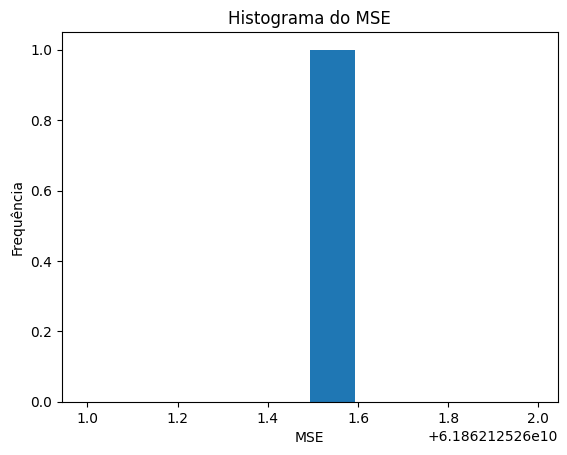

In [18]:
# Histograma do MSE
plt.hist(mse_boot)
plt.xlabel("MSE")
plt.ylabel("Frequência")
plt.title("Histograma do MSE")
plt.show()

In [19]:
# Best subset selection
from sklearn.feature_selection import RFE
from sklearn.feature_selection import SequentialFeatureSelector

In [20]:
rfe = RFE(estimator=LinearRegression(), n_features_to_select=5)
rfe.fit(X_train, y_train)

RFE(estimator=LinearRegression(), n_features_to_select=5)

In [21]:
feature_names = X_train.columns


In [22]:
selected_features = feature_names[rfe.support_]
print("Features selecionadas:", selected_features)

Features selecionadas: Index(['PE1', 'PE2', 'PE3', 'PE4', 'TP2'], dtype='object')


In [23]:
# Fazer predições
y_pred_rfe = rfe.predict(X_val)


In [24]:
# Calcular e mostrar métricas de erro
mse_rfe = mean_squared_error(y_val, y_pred_rfe)
r2_rfe = r2_score(y_val, y_pred_rfe)

print(f"R2 Score: {r2_rfe}")
print(f"MSE: {mse_rfe}")

R2 Score: -0.6963617939528246
MSE: 238206823470.17795


In [25]:
# Forward Subset Selection
forward_selector = SequentialFeatureSelector(LinearRegression(), n_features_to_select=5, direction='forward')
forward_selector.fit(X_train, y_train)

SequentialFeatureSelector(estimator=LinearRegression(), n_features_to_select=5)

In [26]:
forward_features = np.array(feature_names)[forward_selector.get_support()]

In [27]:
print(f"Features selecionadas (Forward Subset Selection): {forward_features}")

Features selecionadas (Forward Subset Selection): ['FM1' 'PE1' 'PE3' 'TP1' 'TP2']


In [28]:

# Backward Subset Selection
backward_selector = SequentialFeatureSelector(LinearRegression(), n_features_to_select=5, direction='backward')
backward_selector.fit(X_train, y_train)


SequentialFeatureSelector(direction='backward', estimator=LinearRegression(),
                          n_features_to_select=5)

In [29]:
np.array(feature_names)[backward_selector.get_support()]

array(['PE1', 'PE3', 'PE4', 'TP1', 'TP2'], dtype=object)

In [30]:
from sklearn.preprocessing import PolynomialFeatures, KBinsDiscretizer, SplineTransformer
from sklearn.pipeline import make_pipeline, Pipeline

In [31]:
# Regressão polinomial
X_train_poly = PolynomialFeatures(degree=2).fit_transform(X_train)
X_val_poly = PolynomialFeatures(degree=2).fit_transform(X_val)

In [32]:
# Efetuar a regressão polinomial
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

LinearRegression()

In [33]:
# Fazer predições
y_pred_poly_val = model_poly.predict(X_val_poly)
y_pred_poly_train = model_poly.predict(X_train_poly)

In [34]:
# Calcular as métricas de erro de treino de teste
mse_poly_train = mean_squared_error(y_train, y_pred_poly_train)
r2_poly_train = r2_score(y_train, y_pred_poly_train)
print(f"R2 Score: {r2_poly_train}")
print(f"MSE: {mse_poly_train}")

R2 Score: 0.9025749727738253
MSE: 13565871545.064182


In [35]:
mse_poly_val = mean_squared_error(y_val, y_pred_poly_val)
r2_poly_val = r2_score(y_val, y_pred_poly_val)
print(f"R2 Score: {r2_poly_val}")
print(f"MSE: {mse_poly_val}")

R2 Score: -69.50910223527643
MSE: 9901041941095.68


In [36]:
# Dados do model
print(f"Coefficients: {model_poly.coef_}")
print(f"Intercept: {model_poly.intercept_}")
print(f"Número de parâmetros: {len(model_poly.coef_)}")

Coefficients: [ 1.66143479e-03  9.07845769e+07  1.00659940e+09 -1.01106749e+09
 -3.96125730e+07  2.13287005e+08 -5.92605211e+06  4.35986255e+06
 -1.53704147e+06 -2.15237067e+06 -4.71580977e+06 -1.34297548e+08
  5.27635179e+07  5.76769476e+06 -8.78191433e+06 -5.07705468e+08
  3.28983696e+08 -3.96961712e+08 -9.49487657e+06 -4.38635488e+07
  3.96940183e+06  1.03218166e+08  7.88994958e+08 -3.57644600e+08
 -2.28328410e+07  1.27715210e+08 -1.57950185e+08  1.16734391e+08
  1.03687454e+08 -2.04373263e+08 -1.51289626e+07 -3.43152264e+07
  7.17273530e+07 -1.53915477e+06  3.46492544e+06 -1.69625329e+06]
Intercept: 1527942566.7957058
Número de parâmetros: 36


In [37]:
len(X_train.columns)

7

In [38]:
# Criar as regiões para a função degrau
step_function = Pipeline([("binning", KBinsDiscretizer(n_bins=10, encode="onehot-dense")), ("regressor", LinearRegression())])

In [39]:
# Ajustar o modelo da função degrau
step_function.fit(X_train, y_train)

Pipeline(steps=[('binning', KBinsDiscretizer(encode='onehot-dense', n_bins=10)),
                ('regressor', LinearRegression())])

In [40]:

# Fazer as predições nos dados de treino e teste
y_train_step = step_function.predict(X_train)
y_val_step = step_function.predict(X_val)

In [41]:
# Calcular as métricas de erro e mostrar na tela
mse_train_step = mean_squared_error(y_train, y_train_step)
mse_val_step = mean_squared_error(y_val, y_val_step)
r2_train_step = r2_score(y_train, y_train_step)
r2_val_step = r2_score(y_val, y_val_step)

print(f"R2 Score Train: {r2_train_step}")
print(f"MSE Train: {mse_train_step}")

print(f"R2 Score Val: {r2_val_step}")
print(f"MSE Val: {mse_val_step}")


R2 Score Train: 0.7541267131738548
MSE Train: 34236433085.133144
R2 Score Val: 0.6955560338708839
MSE Val: 42750685823.507744


In [42]:
# Ajustar um modelo de splines
spline_model = make_pipeline(SplineTransformer(n_knots=2, degree=2, knots="uniform"), LinearRegression())

In [43]:
# Ajustar o modelo continuação
spline_model.fit(X_train, y_train)

Pipeline(steps=[('splinetransformer', SplineTransformer(degree=2, n_knots=2)),
                ('linearregression', LinearRegression())])

In [44]:
# Fazer as predições para os dados de treinamento e validação
y_train_spline = spline_model.predict(X_train)
y_val_spline = spline_model.predict(X_val)

In [45]:
# Calcular as métricas R2 e MSE e mostrar na tela
mse_train_spline = mean_squared_error(y_train, y_train_spline)
mse_val_spline = mean_squared_error(y_val, y_val_spline)

r2_train_spline = r2_score(y_train, y_train_spline)
r2_val_spline = r2_score(y_val, y_val_spline)

print(f"R2 Score Train: {r2_train_spline}")
print(f"MSE Train: {mse_train_spline}")
print(f"MSE Val: {mse_val_spline}")
print(f"R2 Score Val: {r2_val_spline}")

R2 Score Train: 0.6897714140644058
MSE Train: 43197536261.7963
MSE Val: 49913731069.101074
R2 Score Val: 0.644545252122639
